# ARIMA Model — System Identification Walkthrough

This notebook demonstrates the four-step system identification process for a **non-stationary** univariate time series using the **ARIMA** model class.

| Step | Task | Tool |
|------|------|------|
| 1 | Choose a model class | Raw ACF; differencing to achieve stationarity |
| 2 | Select model order | `uniAnal` on $\nabla y$ — ACF, PACF, GPAC |
| 3 | Estimate parameters | `estimate`, `pmoddisp` |
| 4 | Validate the model | `partoacf_pmod`, `uniAnal` on residuals, `uniChi` |

**Dataset:** Box-Jenkins Series C — Chemical Temperature (226 observations)

The ARIMA($n_d$, $d$, $n_c$) model is

$$D(q)\,\nabla^d y(t) = C(q)\,e(t)$$

where $\nabla = 1 - q^{-1}$ is the backward difference operator, so $\nabla y(t) = y(t) - y(t-1)$ and $\nabla^d$ denotes $d$ successive applications, and

$$D(q) = 1 + d_1 q^{-1} + \cdots + d_{n_d} q^{-n_d}, \qquad C(q) = 1 + c_1 q^{-1} + \cdots + c_{n_c} q^{-n_c}$$

Differencing $d$ times converts a non-stationary (integrated) series into a stationary one, after which a standard ARMA($n_d$, $n_c$) model is fitted to $\nabla^d y(t)$.  The noise transfer function is $H(q) = C(q)/D(q)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd

# Add TimeSeries root directory to path
current_dir = os.getcwd()
timeseries_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
if timeseries_root not in sys.path:
    sys.path.insert(0, timeseries_root)

from TimeSeriesSRC.Model.model import pmodel
from TimeSeriesSRC.Model.estimate import estimate
from TimeSeriesSRC.Model.selpmod import func_selpmod as selpmod
from TimeSeriesSRC.basefunctions.uniAnal import func_uniAnal as uniAnal
from TimeSeriesSRC.basefunctions.uniChi import func_uniChi as uniChi
from TimeSeriesSRC.basefunctions.partoacf import func_partoacf_pmod as partoacf_pmod
from TimeSeriesSRC.Model.pmodmse import func_pmodmse as pmodmse
from TimeSeriesSRC.Model.pmoddisp import func_pmoddisp as pmoddisp
from TimeSeriesSRC.Model.pmoddisp import func_pmodpzplot as pmodpzplot

np.random.seed(42)
print('Setup complete.')

Setup complete.


## Series C — Chemical Temperature

Box-Jenkins Series C is a univariate time series of 226 temperature measurements from a chemical process.  There is no observed external input.  The raw series exhibits a gradual drift, suggesting non-stationarity that will require first differencing ($d = 1$) before an ARMA model can be fitted.  The series mean is removed for numerical centering.

Loaded chemical temperature data: N=226 samples
y: mean=-1.19e-15, std=2.055


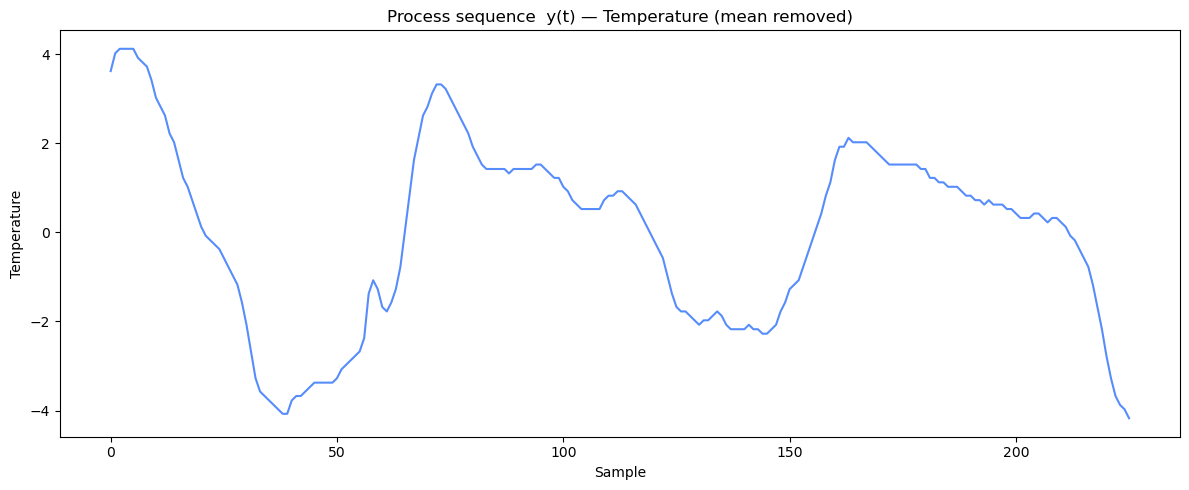

In [2]:
data_path = os.path.join(timeseries_root, 'TimeSeriesSRC', 'TestData',  'Series_C_Chemical_Temperature.csv')
df = pd.read_csv(data_path)
y = np.array(df['Temperature'])
y = y - np.mean(y)
N = y.size
print(f'Loaded chemical temperature data: N={N} samples')
print(f'y: mean={y.mean():.2e}, std={y.std():.3f}')

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(y)
ax.set_title('Process sequence  y(t) — Temperature (mean removed)')
ax.set_xlabel('Sample')
ax.set_ylabel('Temperature')
plt.tight_layout()
plt.show()

## Step 1 — Choose a Model Class

With no external input, the general prediction model $y(t) = G(q)u(t) + H(q)e(t)$ reduces to a pure noise model.  Before choosing ARMA or ARIMA, we must determine whether the series is **stationary**.

A stationary series has a constant mean and variance; its ACF decays quickly to zero.  A non-stationary (integrated) series has a slowly decaying or non-decaying ACF.  We apply `uniAnal` to the raw (mean-removed) series to check.

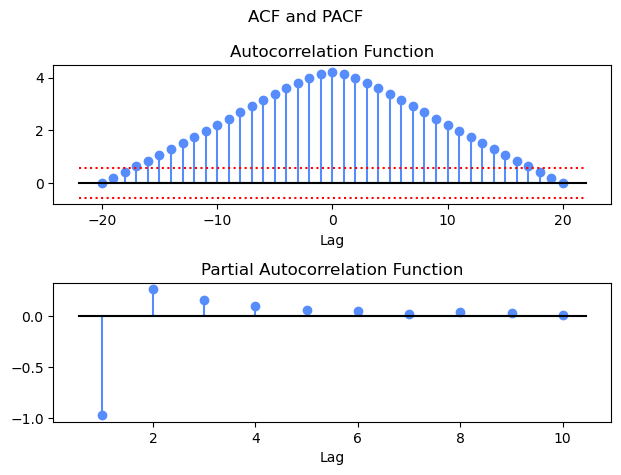

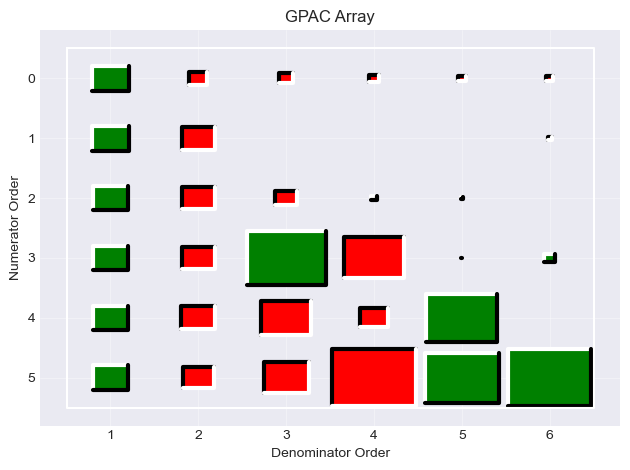

In [3]:
acf_raw, pacf_raw, gpac_raw = uniAnal(y, na=20, nump=10, nrg=6, ncg=6)

### Stationarity Check

A slowly decaying ACF — where values remain large across many lags — is the hallmark of a non-stationary series.  First differencing ($d = 1$) transforms $y(t)$ to

$$\nabla y(t) = y(t) - y(t-1)$$

which removes a stochastic linear trend (random-walk behaviour) and should yield a stationary series whose ACF decays quickly.  We compute and plot $\nabla y$ to verify.

Differenced series: N=225 samples
∇y: mean=-3.47e-02, std=0.231


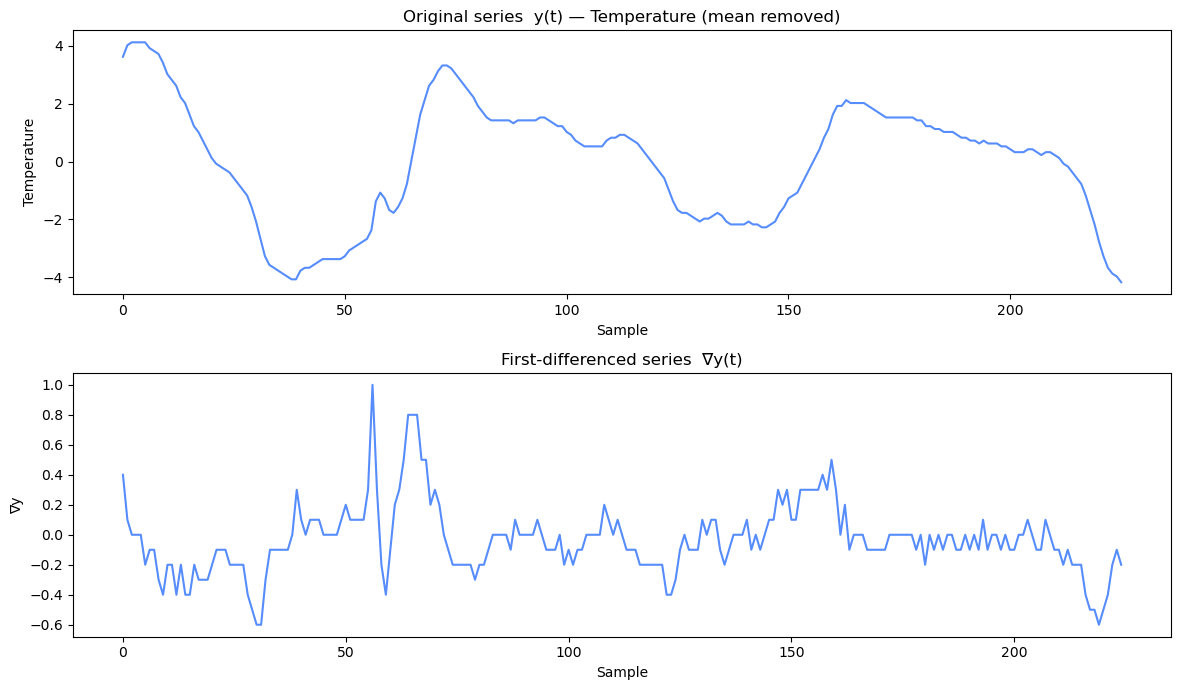

In [4]:
dy = np.diff(y)   # nabla y(t) = y(t) - y(t-1)
Nd = dy.size
print(f'Differenced series: N={Nd} samples')
print(f'\u2207y: mean={dy.mean():.2e}, std={dy.std():.3f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(y)
axes[0].set_title('Original series  y(t) — Temperature (mean removed)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Temperature')

axes[1].plot(dy)
axes[1].set_title('First-differenced series  \u2207y(t)')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('\u2207y')
plt.tight_layout()
plt.show()

## Step 2 — Select Model Order

We apply `uniAnal` to the differenced series $\nabla y(t)$ to identify the ARMA orders $n_d$ and $n_c$.  Together with $d = 1$, these specify the ARIMA($n_d$, 1, $n_c$) model.

- **ACF** of $\nabla y$ — should now decay quickly, confirming that differencing achieved stationarity.
- **PACF** — cuts off sharply after lag $n_d$ for a pure AR component.
- **GPAC** — a column of approximately constant (near-zero) entries identifies $n_d$; the row where the constant pattern begins identifies $n_c$.

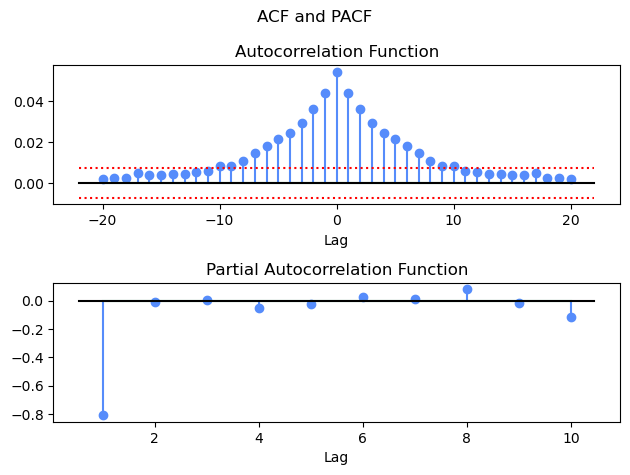

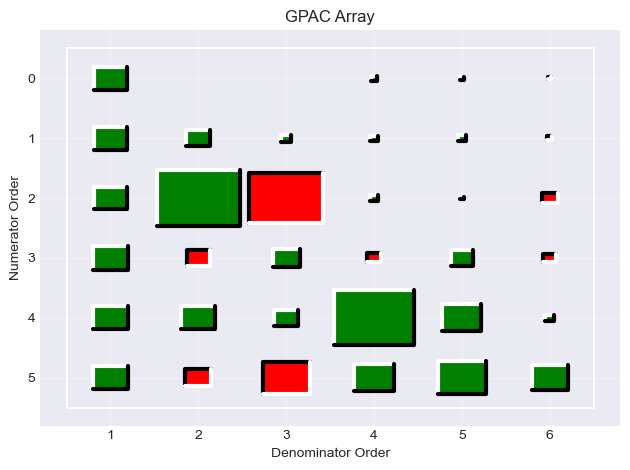

In [5]:
acf_dy, pacf_dy, gpac_dy = uniAnal(dy, na=20, nump=10, nrg=6, ncg=6)

### GPAC Interpretation

In the GPAC table for $\nabla y$:

- The **column index** of the first approximately constant column is the candidate AR order $n_d=1$.
- The **row where the constant pattern begins** is the candidate MA order $n_c=0$. Also, after the first column, the remainder of row 0 is close to zero.

Use these to form the ARIMA(1, 1, 0) model estimated in Step 3.

## Step 3 — Estimate Parameters

The ARIMA model is built with `pmodel` using `diff=[1]`.  The `estimate` function receives the **original** (undifferenced) series $y$ — it pre-differences internally before running the Levenberg-Marquardt optimizer, so the parameters are estimated by minimising the mean-squared prediction error on $\nabla y$.

For **validation** (residuals, ACF comparison, chi-square test), `predict` and `uniChi` must receive the **differenced** series $\nabla y$ (`dy`), because the fitted ARMA model operates on $\nabla y$.

`pmoddisp` prints the estimated parameters with ±2σ confidence intervals.  `pmodpzplot` shows the pole-zero map of the noise transfer function $H(q) = C(q)/D(q)$, confirming that the ARMA part (acting on $\nabla y$) is stable and invertible.

Epoch 0/100 Time 0.011419057846069336 PMODMSE 0.051687648347063485/0 Gradient 9.537347362697533/0.0001 mu 0.001/10000000000.0


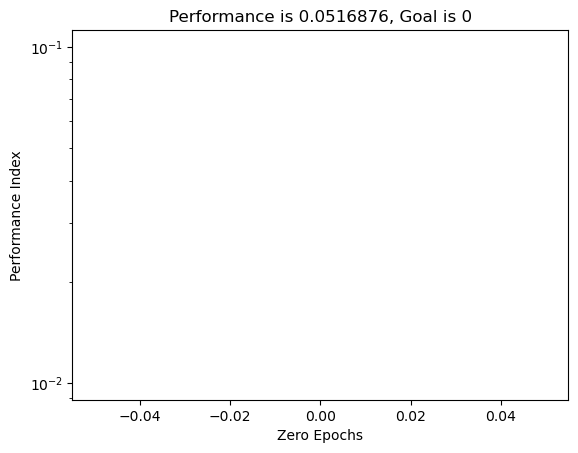

6.40679726109569e-09 0.0001
Epoch 2/100 Time 0.17670893669128418 PMODMSE 0.01855067395264119/0 Gradient 6.40679726109569e-09/0.0001 mu 1e-05/10000000000.0


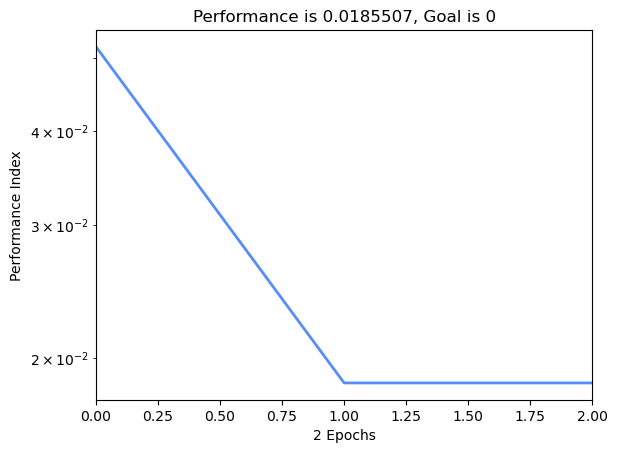

ESTIMLM, Minimum gradient reached, performance goal was not met.




In [6]:
pmod = pmodel('arma', nc=[0], nd=[1], diff=[1], per=[])
pmod, trec, stat = estimate(pmod, y)

Parameter estimates — ARMA model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  d1      -0.8131       0.0780   (   -0.8911,    -0.7351)

  Residual std  σ = 0.136201
  Residual var  σ² = 0.018551


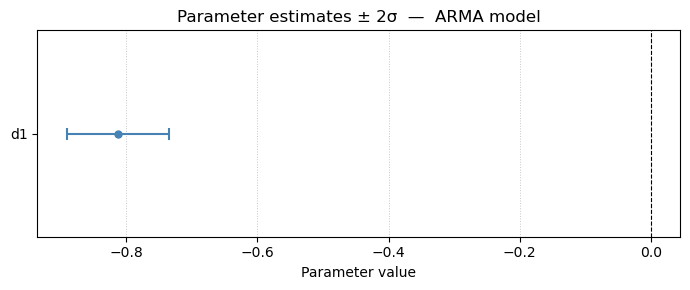

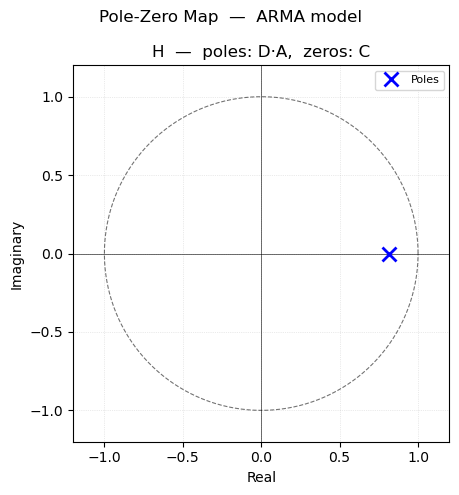

In [7]:
pmoddisp(pmod, stat)
pmodpzplot(pmod)
plt.show()

## Step 4 — Validate the Model

A well-fitted ARIMA model should leave **white residuals**.  We check this in three ways:

1. **Theoretical ACF** — `partoacf_pmod` computes the exact autocovariance function of the fitted ARMA part using the Yule-Walker method.  We compare it against the experimental ACF of $\nabla y$ from Step 2.
2. **Residual ACF** — plot the ACF, PACF, and GPAC of the residuals with `uniAnal`.  All values should fall within the 95% confidence bounds.
3. **Statistical test** — `uniChi` performs the portmanteau chi-square test on the residuals.  A p-value > 0.05 indicates an adequate model.

### Check 1 — Theoretical vs Experimental ACF

`partoacf_pmod` uses the fitted ARMA polynomials $D(q)$ and $C(q)$ together with the noise variance to compute the theoretical autocovariance function of the stationary part of the model.  Close agreement with the experimental ACF of $\nabla y$ confirms that the model has captured the correlation structure of the differenced series.

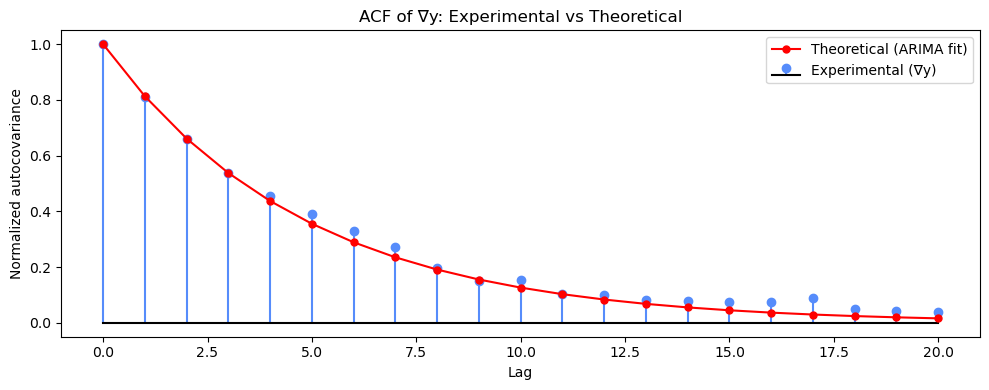

In [8]:
# Noise variance estimate from one-step prediction errors on the differenced series
var_e, _ = pmodmse(pmod, dy)

# Theoretical autocovariance function from the fitted ARMA part
lagmax = 21
acf_theory, _, _ = partoacf_pmod(pmod, var_e, lagmax)

# Experimental ACF of nabla y from Step 2 (na=20 -> center index is 20)
acf_exp = acf_dy.squeeze()[20:20 + lagmax]

# Normalize both to lag-0 = 1 for a shape comparison
acf_theory_norm = acf_theory / acf_theory[0]
acf_exp_norm    = acf_exp    / acf_exp[0]

lags = np.arange(lagmax)
fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(lags, acf_exp_norm, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='Experimental (∇y)')
ax.plot(lags, acf_theory_norm, 'r-o', markersize=5, linewidth=1.5, label='Theoretical (ARIMA fit)')
ax.set_title('ACF of ∇y: Experimental vs Theoretical')
ax.set_xlabel('Lag')
ax.set_ylabel('Normalized autocovariance')
ax.legend()
plt.tight_layout()
plt.show()

Residual std: 0.1360


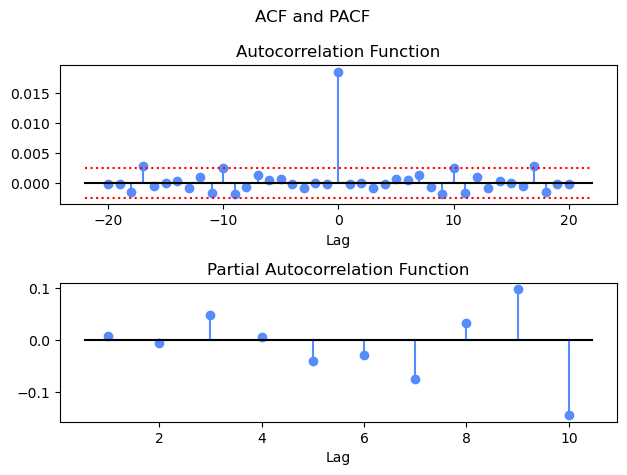

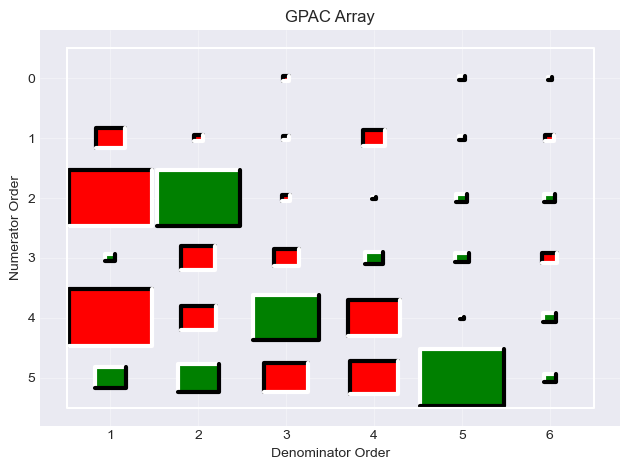

In [9]:
e = dy - pmod.predict(dy)
print(f'Residual std: {e.std():.4f}')
acf_e, pacf_e, gpac_e = uniAnal(e, na=20, nump=10, nrg=6, ncg=6)

In [10]:
# Chi-square statistic for ARIMA model
passed, q_arima, n_arima, pval = uniChi(pmod, dy)

print(f'\nChi-square test on ARIMA model:  Q={q_arima:.2f},  df={n_arima},  pass={bool(passed)}, pval={pval:.3f}')
print('(pass=True means residuals are consistent with white noise at 95% confidence)')


pval: 0.32773951655147526
alpha: 0.05
pr: 0.6722604834485247
q: 21.169511113923555

Chi-square test on ARIMA model:  Q=21.17,  df=19,  pass=True, pval=0.328
(pass=True means residuals are consistent with white noise at 95% confidence)


## Conclusion

The chi-square test passes (p-value > 0.05), the residual ACF and PACF fall within the 95% confidence bounds, and the theoretical and experimental ACFs of $\nabla y$ are broadly consistent — confirming that the **ARIMA(1, 1, 0)** model is validated for Box-Jenkins Series C.

The fitted pole-zero map from `pmodpzplot` confirms that the AR polynomial is stable (pole inside the unit circle).

If the residuals show remaining structure, return to **Step 2** and adjust $n_d$ or $n_c$, or use `selpmod` in the next section for an automated grid search.  The BIC-optimal model identified by `selpmod` is typically **ARIMA(1, 1, 1)**, which achieves an even lower Q statistic.

## Automated Model Selection with `selpmod`

`selpmod` searches a grid of ARMA orders applied to the differenced series (fixed $d = 1$) and selects the best ARIMA structure by AIC and BIC.  We search over $n_d \in \{1, 2, 3\}$ and $n_c \in \{0, 1, 2, 3\}$ — 12 combinations — to verify the manually chosen structure.

In [11]:
arima_spec = {
    'models': [{
        'type': 'arma',
        'nc': [0, 1, 2, 3],
        'nd': [1, 2, 3],
        'diff': [1]
    }]
}
result  = selpmod(arima_spec, y)
aicmod  = result['arma']['aicmod']
bicmod  = result['arma']['bicmod']
aicstat = result['arma']['aicstat']
bicstat = result['arma']['bicstat']

Selecting the best ARMA prediction model
arma: Combination 1 out of 12 total  [nc=0, nd=1].  aic = -3.9784, bic = -3.9632
arma: Combination 2 out of 12 total  [nc=0, nd=2].  aic = -3.9696, bic = -3.9392
arma: Combination 3 out of 12 total  [nc=0, nd=3].  aic = -3.9607, bic = -3.9151
arma: Combination 4 out of 12 total  [nc=1, nd=1].  aic = -3.9696, bic = -3.9392
arma: Combination 5 out of 12 total  [nc=1, nd=2].  aic = -3.9640, bic = -3.9185
arma: Combination 6 out of 12 total  [nc=1, nd=3].  aic = -3.9528, bic = -3.8921
arma: Combination 7 out of 12 total  [nc=2, nd=1].  aic = -3.9607, bic = -3.9151
arma: Combination 8 out of 12 total  [nc=2, nd=2].  aic = -3.9552, bic = -3.8944
arma: Combination 9 out of 12 total  [nc=2, nd=3].  aic = -3.9512, bic = -3.8753
arma: Combination 10 out of 12 total  [nc=3, nd=1].  aic = -3.9556, bic = -3.8949
arma: Combination 11 out of 12 total  [nc=3, nd=2].  aic = -3.9469, bic = -3.8710
arma: Combination 12 out of 12 total  [nc=3, nd=3].  aic = -4.0059

Best AIC model: ARIMA(nd=3, d=1, nc=3)
Best BIC model: ARIMA(nd=1, d=1, nc=0)

=== Best AIC model ===
Parameter estimates — ARMA model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  c1      -0.8055       0.1723   (   -0.9778,    -0.6332)
  c2       1.0752       0.1261   (    0.9491,     1.2013)
  c3      -0.0741       0.1760   (   -0.2501,     0.1019)
  d1      -1.5820       0.1045   (   -1.6865,    -1.4776)
  d2       1.5928       0.0962   (    1.4966,     1.6890)
  d3      -0.8015       0.1003   (   -0.9019,    -0.7012)

  Residual std  σ = 0.131388
  Residual var  σ² = 0.017263


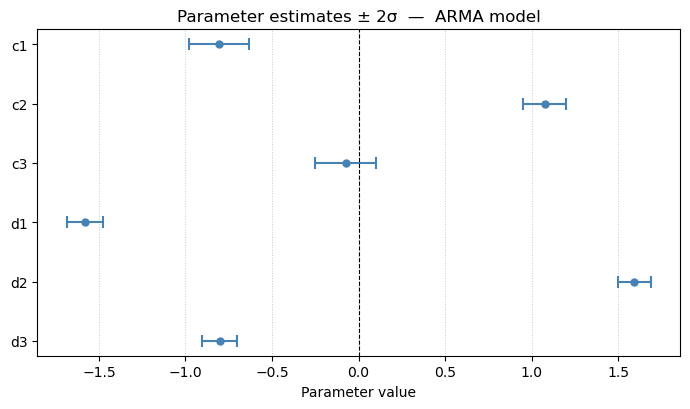

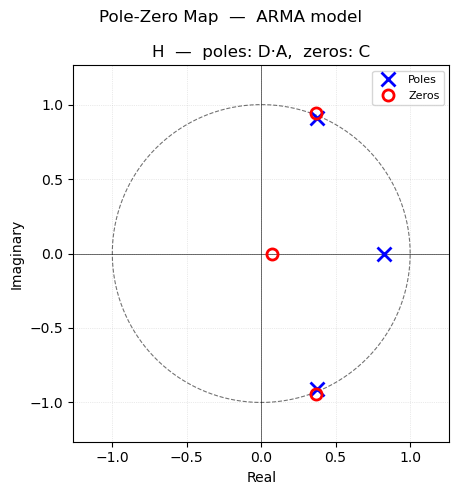


=== Best BIC model ===
Parameter estimates — ARMA model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  d1      -0.8131       0.0780   (   -0.8911,    -0.7351)

  Residual std  σ = 0.136201
  Residual var  σ² = 0.018551


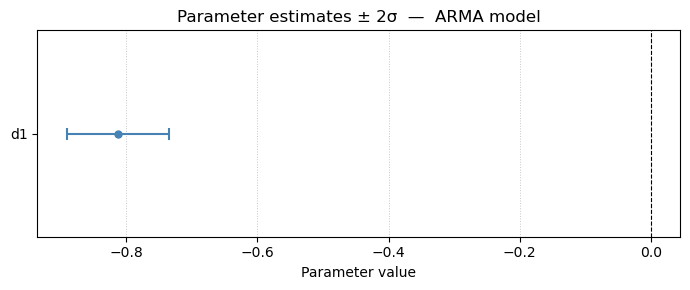

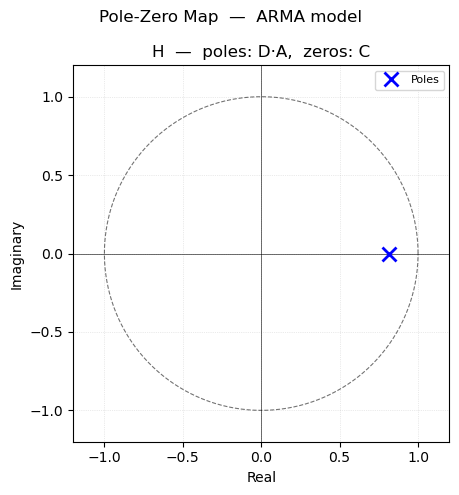

In [12]:
print(f'Best AIC model: ARIMA(nd={int(aicmod.nd[0])}, d=1, nc={int(aicmod.nc[0])})')
print(f'Best BIC model: ARIMA(nd={int(bicmod.nd[0])}, d=1, nc={int(bicmod.nc[0])})')

print('\n=== Best AIC model ===')
pmoddisp(aicmod, aicstat)
pmodpzplot(aicmod)
plt.show()

print('\n=== Best BIC model ===')
pmoddisp(bicmod, bicstat)
pmodpzplot(bicmod)
plt.show()

Note that the optimal AIC model added additional c and d parameters. The chi-square test was passed, but we can see that the additional parameters produced approximate pole / zero cancellations. The optimal BIC model is the same one that we developed from the initial analysis of the GPAC.